# Q-Learning in a Multi-Agent Foraging Grid Environment

### Objective
Implement Q-learning for **Forager Agents** to learn an optimal strategy for collecting **renewable Food Resources** in a **10×10 grid** with **obstacles**.

### Key Requirements Implemented
- Grid: **10×10** with **≥5 obstacles** (impassable cells)
- Food: **10 food resources** placed randomly and **respawn** after collection
- Rewards:
  - **+10** for collecting food
  - **−1** for each step without food
  - **−5** for collisions (agents attempting the same cell)
- Experiments:
  - Single agent: **200** and **1000** episodes
  - Multi-agent: **3 agents** with **Independent Q-tables vs Shared Q-table**
- Outputs:
  - CSV logs + learning curves (reward and food collected per episode)


In [9]:
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Basic libraries:
# - random / numpy: for randomness and numerical ops
# - pandas: to store results in tables and CSVs
# - matplotlib: to plot learning curves
# - defaultdict: for easy Q-table initialization
# =========================================================


# Grid size: 10x10 environment
GRID_SIZE = 10

# Number of renewable food resources
FOOD_COUNT = 10

# At least five impassable cells as obstacles
OBSTACLE_COUNT = 5

# Episode length (kept fixed so total reward is comparable)
MAX_STEPS_PER_EPISODE = 200


# ===== Q-learning parameters =====
# Learning rate: how fast the agent updates its knowledge
ALPHA = 0.15

# Discount factor: importance of future rewards
GAMMA = 0.95

# Exploration rate: probability of choosing a random action
EPSILON = 0.2


# ===== Rewards =====
# +10 when food is collected
REWARD_FOOD = 10

# -1 for each step without food (living cost)
REWARD_STEP = -1

# -5 when agents collide in multi-agent scenario
REWARD_COLLISION = -5


# Action space: the four allowed moves in the grid
ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT"]


# ===== Reproducibility =====
# Setting seeds makes results repeatable
SEED = 1
random.seed(SEED)
np.random.seed(SEED)


# =========================================================
# Helper functions
# These are small utilities to keep the main code clean
# =========================================================

def move_from_action(x, y, action):
    """
    Converts an action name into a new (x, y) position.
    This represents how the agent physically moves in the grid.
    """
    if action == "UP": return x - 1, y
    if action == "DOWN": return x + 1, y
    if action == "LEFT": return x, y - 1
    if action == "RIGHT": return x, y + 1
    raise ValueError("Unknown action")


def sign(v):
    """
    Returns the sign of a value:
    -1 for negative, 0 for zero, +1 for positive.
    Used to encode only the DIRECTION to food, not exact distance,
    which helps keep the state space small for Q-learning.
    """
    return 0 if v == 0 else (1 if v > 0 else -1)


def moving_average(values, window=25):
    """
    Computes a simple moving average for smoothing learning curves.
    This is only for visualization, not used in learning itself.
    """
    values = list(values)
    if window <= 1:
        return values
    out = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        chunk = values[start:i+1]
        out.append(sum(chunk) / len(chunk))
    return out


# =========================================================
# Plotting utilities
# These functions generate the learning curves required
# (reward vs episode, food vs episode).
# =========================================================

def plot_raw_ma(df, y_col, title, y_label, color="royalblue", window=25):
    """
    Plots:
    - Raw values (noisy)
    - Moving average (smooth trend)
    This helps visually show learning progress over time.
    """
    x = df["Episode"].values
    y = df[y_col].values
    y_ma = moving_average(y, window=window)

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, color=color, alpha=0.20, linewidth=1, label="Raw")
    plt.plot(x, y_ma, color=color, linewidth=2.7,
             label=f"Moving Avg (window={window})")
    plt.title(title, fontweight="bold")
    plt.xlabel("Episode")
    plt.ylabel(y_label)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_compare(ind_df, sh_df, y_col, title, y_label,
                 color_ind="darkorange", color_sh="purple", window=25):
    """
    Plots independent vs shared Q-table results on the same figure.
    This directly supports the rubric requirement to compare
    learning behavior between the two strategies.
    """
    x = ind_df["Episode"].values
    yi = ind_df[y_col].values
    ys = sh_df[y_col].values

    yi_ma = moving_average(yi, window=window)
    ys_ma = moving_average(ys, window=window)

    plt.figure(figsize=(10, 5))

    # Independent learning curves
    plt.plot(x, yi, color=color_ind, alpha=0.18, linewidth=1,
             label="Independent (raw)")
    plt.plot(x, yi_ma, color=color_ind, linewidth=2.7,
             label=f"Independent (MA {window})")

    # Shared learning curves
    plt.plot(x, ys, color=color_sh, alpha=0.18, linewidth=1,
             label="Shared (raw)")
    plt.plot(x, ys_ma, color=color_sh, linewidth=2.7,
             label=f"Shared (MA {window})")

    plt.title(title, fontweight="bold")
    plt.xlabel("Episode")
    plt.ylabel(y_label)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Design Choices: State, Actions, and Q-Learning

### Actions
Agents can move in 4 directions: **UP, DOWN, LEFT, RIGHT**.  
If an action would move the agent **outside the grid** or into an **obstacle**, the agent **stays in place**.

### State Representation
To keep the state space small and still support “foraging”, the state is:
- **Agent position (x, y)**
- **Direction to the closest food** as `(dx_sign, dy_sign)` using Manhattan distance  
  where `dx_sign ∈ {−1, 0, 1}` and `dy_sign ∈ {−1, 0, 1}`

So the state is: **(x, y, dx_sign, dy_sign)**.

This helps the agent learn “move toward food” without needing the full map as input.

### Q-Learning Update
Q-values are updated using the standard Bellman update:
\[
Q(s,a) \leftarrow Q(s,a) + \alpha\big[r + \gamma\max_{a'}Q(s',a') - Q(s,a)\big]
\]
Parameters used:
- Learning rate **α = 0.15**
- Discount factor **γ = 0.95**
- Exploration **ε = 0.2 (fixed)**

### Exploration (ε-greedy)
With probability ε, the agent chooses a random action (exploration).  
Otherwise it chooses the best known action (exploitation).  
Ties between actions with equal Q-values are broken **randomly** to avoid bias.

In [10]:
class GridEnvironment:
    def __init__(self, grid_size=10, food_count=10, obstacle_count=5, seed=1):
        # Store environment configuration grid size: 10x10, 10 food, >=5 obstacles)
        self.grid_size = grid_size
        self.food_count = food_count
        self.obstacle_count = obstacle_count

        # Dedicated RNG for the environment so randomness is controlled by the seed
        self.rng = random.Random(seed)

        # Create the first world layout immediately
        self.reset()

    def _random_empty_cell(self, forbidden):
        """
        Returns a random cell (x, y) that is NOT in the forbidden set.
        We use this for placing obstacles, food, and agents without overlap.
        """
        while True:
            cell = (self.rng.randrange(self.grid_size), self.rng.randrange(self.grid_size))
            if cell not in forbidden:
                return cell

    def reset(self, agent_positions=None):
        """
        Resets the environment at the start of each episode.
        This matches the rubric requirement to initialize:
        - random obstacles
        - random food
        - agent starting position(s)
        """

        # -------------------
        # 1) Place obstacles
        # -------------------
        # At least five impassable cells
        self.obstacles = set()
        while len(self.obstacles) < self.obstacle_count:
            self.obstacles.add((self.rng.randrange(self.grid_size), self.rng.randrange(self.grid_size)))

        # -------------
        # 2) Place food
        # -------------
        # 10 random food resources
        self.food = set()
        forbidden = set(self.obstacles)

        # If agent positions were provided (multi-agent), keep food off those cells too
        if agent_positions:
            forbidden |= set(agent_positions)

        # Keep sampling until we have exactly FOOD_COUNT food items placed
        while len(self.food) < self.food_count:
            self.food.add(self._random_empty_cell(forbidden | self.food))

        # --------------
        # 3) Place agents
        # --------------
        # If no starting positions are given, default to single-agent placement
        # placed on an empty cell that is not an obstacle and not food
        if agent_positions is None:
            agent_positions = [self._random_empty_cell(forbidden | self.food)]

        # Store agent positions as a list, where index = agent_id
        self.agent_positions = list(agent_positions)
        return self.agent_positions

    def in_bounds(self, cell):
        """
        Boundary check (agents cannot move outside the grid).
        """
        x, y = cell
        return 0 <= x < self.grid_size and 0 <= y < self.grid_size

    def passable(self, cell):
        """
        Obstacle check (obstacles are impassable).
        """
        return cell not in self.obstacles

    def respawn_food(self, occupied):
        """
        Food respawn logic:
        When an agent collects food, we remove it and respawn a new one in a random empty cell.
        This keeps the resource renewable and ensures there are always FOOD_COUNT items.
        """
        self.food.add(self._random_empty_cell(occupied))

    def closest_food_direction(self, pos):
        """
        This is how the agent 'senses' food:
        It finds the nearest food item using Manhattan distance and returns ONLY the direction:
        (dx_sign, dy_sign) in {-1, 0, +1}.

        Why we do this:
        - It keeps the state small (good for tabular Q-learning)
        - Still gives enough information for the agent to learn "move toward food"
        """
        ax, ay = pos
        best = None
        best_dist = 10**9

        # Find nearest food using Manhattan distance (|dx| + |dy|)
        for fx, fy in self.food:
            d = abs(fx - ax) + abs(fy - ay)
            if d < best_dist:
                best_dist = d
                best = (fx, fy)

        # Safety fallback (normally food always exists because it respawns)
        if best is None:
            return (0, 0)

        fx, fy = best
        return (sign(fx - ax), sign(fy - ay))


class ForagerAgent:
    def __init__(self, agent_id, actions, alpha=0.15, gamma=0.95, epsilon=0.2, shared_q=None):
        # Agent identity (important in multi-agent logs)
        self.id = agent_id

        # Action space (UP/DOWN/LEFT/RIGHT)
        self.actions = actions

        # Q-learning parameters
        self.alpha = alpha
        self.gamma = gamma

        # Exploration rate (epsilon-greedy)
        self.epsilon = epsilon

        # Q-table:
        # - If shared_q is provided -> agents learn into the same table (shared experience)
        # - Otherwise each agent gets its own independent Q-table
        self.q = shared_q if shared_q is not None else defaultdict(lambda: {a: 0.0 for a in actions})

        # Reset counters and episode totals
        self.reset_episode_stats()

    def reset_episode_stats(self):
        """
        Resets all episode-level tracking variables.
        These values are what we store into the CSV.
        """
        self.total_reward = 0
        self.food_collected = 0
        self.steps = 0

        # Track exploration vs exploitation counts
        self.random_actions = 0
        self.greedy_actions = 0

        # Multi-agent behavior tracking
        self.collision_count = 0

    def get_state(self, env, pos):
        """
        State representation used by Q-learning.
        Here state = (agent_x, agent_y, direction_to_closest_food_x, direction_to_closest_food_y)

        Important point for discussion:
        - The agent always knows its own position (it occupies a grid cell)
        - It also senses direction to nearest food (simple local sensing)
        - This supports learning without making the state huge.
        """
        fx_dir, fy_dir = env.closest_food_direction(pos)
        return (pos[0], pos[1], fx_dir, fy_dir)

    def choose_action(self, state):
        """
        Epsilon-greedy action selection.
        With probability epsilon -> explore randomly.
        Otherwise -> exploit the best known action from the Q-table.

        We also track how many times each type happened.
        """
        if random.random() < self.epsilon:
            self.random_actions += 1
            return random.choice(self.actions)

        self.greedy_actions += 1

        # Greedy: choose action with max Q-value.
        # Random tie-breaking is important so the agent doesn't bias toward the first action.
        qvals = self.q[state]
        max_q = max(qvals.values())
        candidates = [a for a in self.actions if qvals[a] == max_q]
        return random.choice(candidates)

    def update_q(self, state, action, reward, next_state):
        """
        Q-learning update rule (rubric requirement):
        Q(s,a) = Q(s,a) + alpha * [reward + gamma * max_a' Q(s',a') - Q(s,a)]

        This is the core learning step where experience updates the policy.
        """
        old_val = self.q[state][action]
        next_max = max(self.q[next_state].values())
        self.q[state][action] = old_val + self.alpha * (reward + self.gamma * next_max - old_val)


def run_single_agent(episodes, seed_offset=0):
    """
    Runs the single-agent training for a given number of episodes.
    Requireds: run for 200 and 1000 episodes.
    Also logs reward, food collected, and exploration counts.
    """
    env = GridEnvironment(GRID_SIZE, FOOD_COUNT, OBSTACLE_COUNT, seed=SEED + seed_offset)
    agent = ForagerAgent(0, ACTIONS, ALPHA, GAMMA, EPSILON)

    rows = []
    for ep in range(1, episodes + 1):
        # Reset agent stats at the start of each episode
        agent.reset_episode_stats()

        # Reset environment and get starting position of the agent
        pos = env.reset(agent_positions=None)[0]

        for _ in range(MAX_STEPS_PER_EPISODE):
            # Build current state
            state = agent.get_state(env, pos)

            # Choose action using epsilon-greedy
            action = agent.choose_action(state)

            # Convert action to proposed movement
            nx, ny = move_from_action(pos[0], pos[1], action)
            target = (nx, ny)

            # Enforce boundary and obstacle rules (rubric)
            if (not env.in_bounds(target)) or (not env.passable(target)):
                target = pos

            # Apply movement
            pos = target

            # Default step penalty
            reward = REWARD_STEP

            # If agent lands on food -> reward +10 and respawn food elsewhere (renewable resource)
            if pos in env.food:
                reward = REWARD_FOOD
                agent.food_collected += 1

                # Remove collected food and respawn new food in an empty cell
                env.food.remove(pos)
                occupied = env.obstacles | env.food | {pos}
                env.respawn_food(occupied)

            # Update Q-table based on transition (s, a, r, s')
            next_state = agent.get_state(env, pos)
            agent.update_q(state, action, reward, next_state)

            # Accumulate totals
            agent.total_reward += reward
            agent.steps += 1

        # Store episode-level results (CSV)
        rows.append({
            "Episode": ep,
            "TotalReward": agent.total_reward,
            "FoodCollected": agent.food_collected,
            "EpisodeLength": agent.steps,
            "RandomActions": agent.random_actions,
            "GreedyActions": agent.greedy_actions
        })

    return pd.DataFrame(rows)


def run_multi_agent(episodes, shared=False, seed_offset=1000):
    """
    Runs the multi-agent training with 3 agents learning concurrently (rubric).
    Two modes:
    - shared=False: independent Q-tables
    - shared=True: shared Q-table among all agents
    This supports the required comparison: independent vs shared learning.
    """
    env = GridEnvironment(GRID_SIZE, FOOD_COUNT, OBSTACLE_COUNT, seed=SEED + seed_offset)

    # Shared table is one dictionary used by all agents (only if shared=True)
    shared_q = defaultdict(lambda: {a: 0.0 for a in ACTIONS}) if shared else None
    agents = [ForagerAgent(i, ACTIONS, ALPHA, GAMMA, EPSILON, shared_q=shared_q) for i in range(3)]

    curve_rows, agent_rows = [], []

    for ep in range(1, episodes + 1):
        # Reset all agents’ stats
        for ag in agents:
            ag.reset_episode_stats()

        # Initialize positions in non-overlapping cells (avoid starting collisions)
        init_positions = []
        forbidden = set()
        for _ in range(3):
            cell = env._random_empty_cell(forbidden | env.obstacles | env.food)
            init_positions.append(cell)
            forbidden.add(cell)

        # Reset environment with these starting positions
        positions = env.reset(agent_positions=init_positions)

        for _ in range(MAX_STEPS_PER_EPISODE):
            states, actions, proposed = [], [], []

            # -------------------
            # 1) Each agent proposes an action and intended move
            # -------------------
            for i, ag in enumerate(agents):
                s = ag.get_state(env, positions[i])
                a = ag.choose_action(s)
                states.append(s); actions.append(a)

                nx, ny = move_from_action(positions[i][0], positions[i][1], a)
                target = (nx, ny)

                # Enforce walls/obstacles
                if (not env.in_bounds(target)) or (not env.passable(target)):
                    target = positions[i]

                proposed.append(target)

            # -------------------
            # 2) Collision resolution (simultaneous move idea)
            # If 2+ agents want the same cell -> collision, penalty -5, bounce back
            # -------------------
            counts = defaultdict(int)
            for cell in proposed:
                counts[cell] += 1

            new_positions = list(positions)
            step_rewards = [REWARD_STEP] * 3
            collided = [False] * 3

            for i in range(3):
                if counts[proposed[i]] > 1:
                    step_rewards[i] = REWARD_COLLISION
                    new_positions[i] = positions[i]   # bounce back (stay)
                    agents[i].collision_count += 1
                    collided[i] = True
                else:
                    new_positions[i] = proposed[i]

            # Apply updated positions after collision resolution
            positions = new_positions

            # -------------------
            # 3) Food collection (only if agent did NOT collide)
            # This prevents weird cases like "collide but still take food".
            # -------------------
            for i, ag in enumerate(agents):
                if (not collided[i]) and (positions[i] in env.food):
                    step_rewards[i] = REWARD_FOOD
                    ag.food_collected += 1

                    env.food.remove(positions[i])
                    occupied = env.obstacles | env.food | set(positions)
                    env.respawn_food(occupied)

            # -------------------
            # 4) Q-learning updates for each agent
            # Each agent learns from its own reward and next state
            # -------------------
            for i, ag in enumerate(agents):
                ns = ag.get_state(env, positions[i])
                ag.update_q(states[i], actions[i], step_rewards[i], ns)
                ag.total_reward += step_rewards[i]
                ag.steps += 1

        # Episode-level curves
        curve_rows.append({
            "Episode": ep,
            "TotalReward_SumAgents": sum(a.total_reward for a in agents),
            "FoodCollected_SumAgents": sum(a.food_collected for a in agents),
            "TotalCollisions_SumAgents": sum(a.collision_count for a in agents),
            "Mode": "Shared" if shared else "Independent"
        })

        # Per-agent logging at end of episode
        for i, ag in enumerate(agents):
            fx, fy = positions[i]
            agent_rows.append({
                "Episode": ep,
                "AgentID": ag.id,
                "FinalX": fx,
                "FinalY": fy,
                "TotalReward": ag.total_reward,
                "FoodCollected": ag.food_collected,
                "CollisionCount": ag.collision_count,
                "EpisodeLength": ag.steps,
                "RandomActions": ag.random_actions,
                "GreedyActions": ag.greedy_actions
        })

    return pd.DataFrame(curve_rows), pd.DataFrame(agent_rows)

## Environment Setup and Food Respawn

### Obstacles
At least **5 obstacles** are placed randomly at the beginning of each episode.
Obstacles are **impassable**, so agents must learn paths around them.

### Food (Renewable Resources)
At the start of each episode, **10 food items** are placed randomly on empty cells.
When an agent collects food:
1. The food is removed from that cell
2. A new food item is **respawned** in a new random empty cell

This keeps the environment dynamic and matches the “renewable resource” requirement.


In [11]:
print("Running required experiments...")

# =========================================================
# SINGLE-AGENT EXPERIMENTS
# =========================================================
# Requires running the simulation for:
# - 200 episodes
# - 1000 episodes
# with a single Forager Agent learning to collect food.

# Run single agent for 200 episodes
single_200 = run_single_agent(200, seed_offset=0)

# Run single agent for 1000 episodes
single_1000 = run_single_agent(1000, seed_offset=1)

# =========================================================
# MULTI-AGENT EXPERIMENTS (3 agents)
# =========================================================
# Requires extending to 3 agents and comparing:
# - Independent Q-tables (each agent learns separately)
# - Shared Q-table (agents share experience)

# Independent Q-tables, 200 episodes
mi_200_curves, mi_200_agents = run_multi_agent(200, shared=False, seed_offset=2000)

# Shared Q-table, 200 episodes
ms_200_curves, ms_200_agents = run_multi_agent(200, shared=True,  seed_offset=3000)

# Independent Q-tables, 1000 episodes
mi_1000_curves, mi_1000_agents = run_multi_agent(1000, shared=False, seed_offset=4000)

# Shared Q-table, 1000 episodes
ms_1000_curves, ms_1000_agents = run_multi_agent(1000, shared=True,  seed_offset=5000)

print("Simulations complete.")

# =========================================================
# SAVE CSV FILES
# =========================================================

# Single-agent CSVs
single_200.to_csv("single_agent_200.csv", index=False)
single_1000.to_csv("single_agent_1000.csv", index=False)

# Multi-agent Independent (per-agent stats at end of each episode)
mi_200_agents.to_csv("multi_agent_independent_200_per_agent.csv", index=False)
mi_1000_agents.to_csv("multi_agent_independent_1000_per_agent.csv", index=False)

# Multi-agent Shared (per-agent stats at end of each episode)
ms_200_agents.to_csv("multi_agent_shared_200_per_agent.csv", index=False)
ms_1000_agents.to_csv("multi_agent_shared_1000_per_agent.csv", index=False)

Running required experiments...
Simulations complete.


## Experiment 1: Single-Agent Learning (200 and 1000 Episodes)

### What is tracked per episode
- **Total reward accumulated** over the episode
- **Food collected** over the episode
- **Episode length** (steps taken)

### How to interpret the graphs
- If the agent learns effectively, we expect:
  - **Total reward trend to increase over time**
  - **Food collected trend to increase over time**
- The plots show:
  - Raw values per episode
  - A moving average trend line to make learning progress clearer

## Experiment 2: Multi-Agent Learning (3 Agents)

Two learning setups are compared:

### 1) Independent Q-tables
Each agent maintains its own Q-table and learns only from its own experience.
This can produce:
- Diverse behaviors
- Potential competition for the same nearby food
- More collisions in crowded situations

### 2) Shared Q-table
All agents update and use the same Q-table (shared experience).
This can lead to:
- Faster learning (more experience per episode)
- A more consistent policy shared across agents
- Possible reduction in collisions if the learned policy spreads agents out

### What is tracked per agent per episode (CSV)
- Agent ID
- Final position (x, y)
- Total reward accumulated
- Food collected
- Collision count
- Episode length

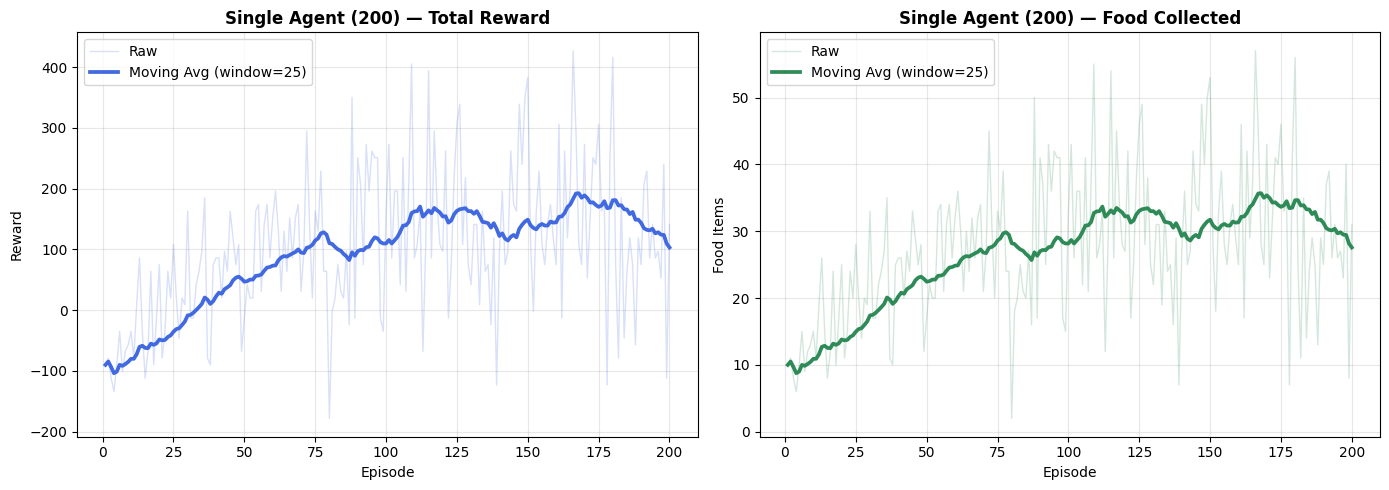

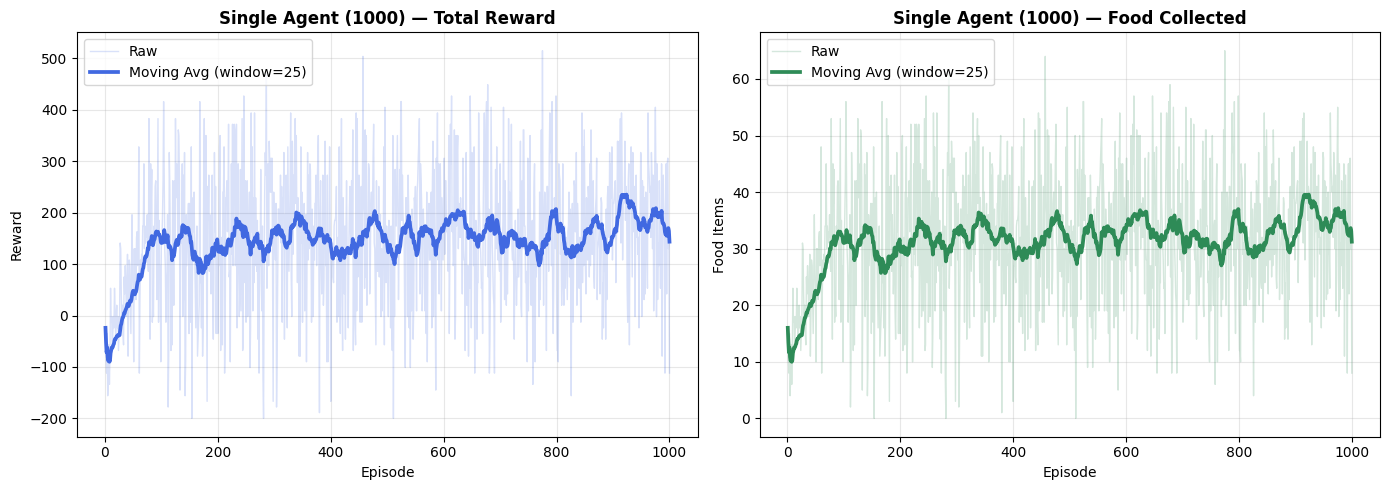

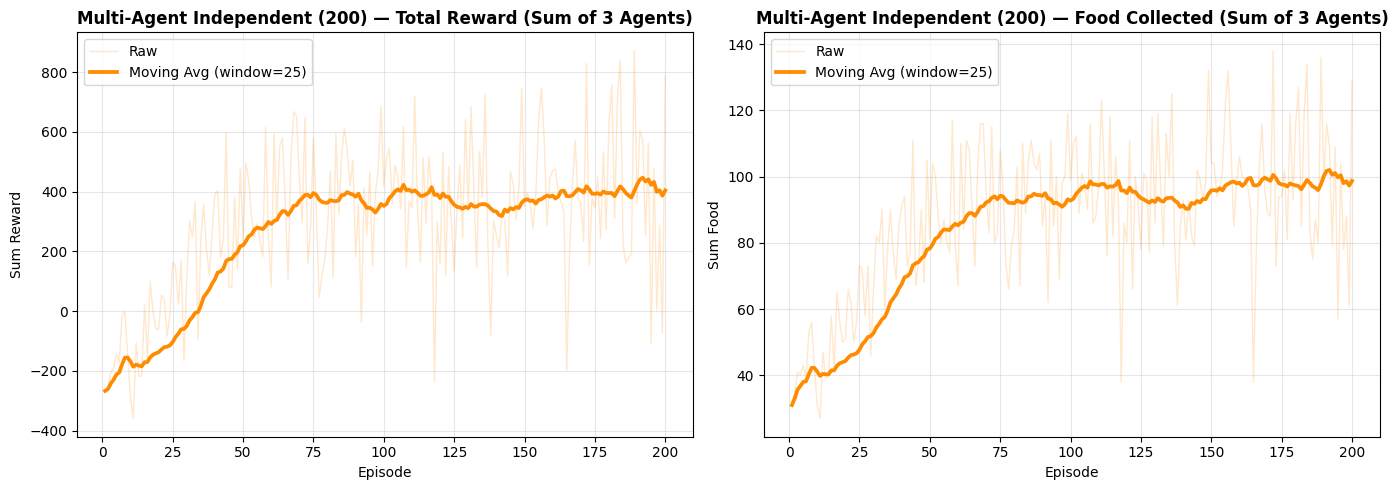

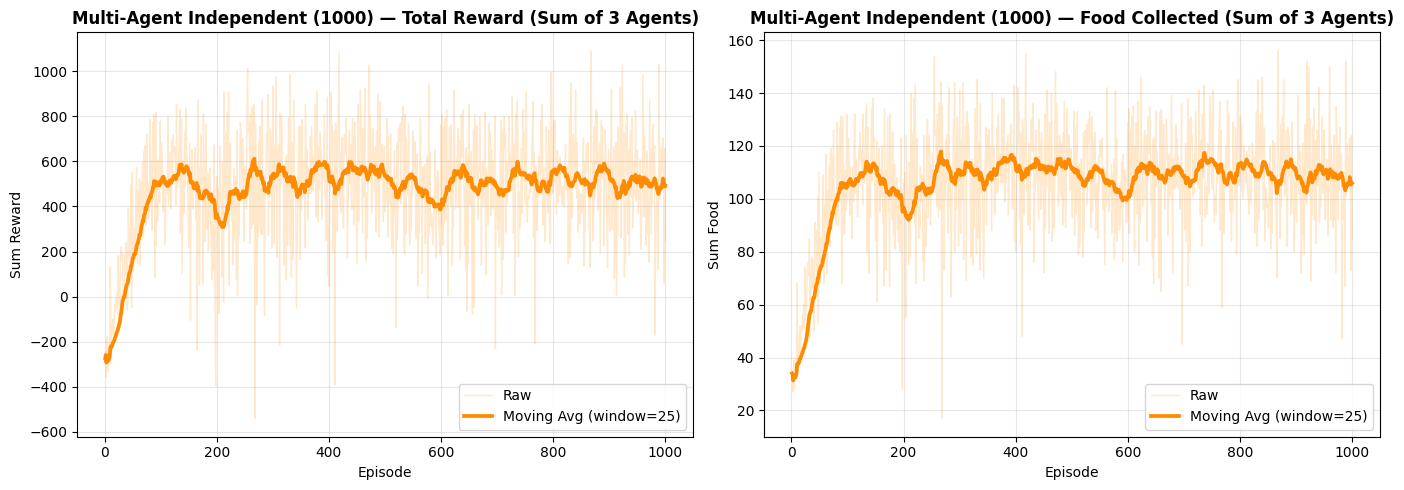

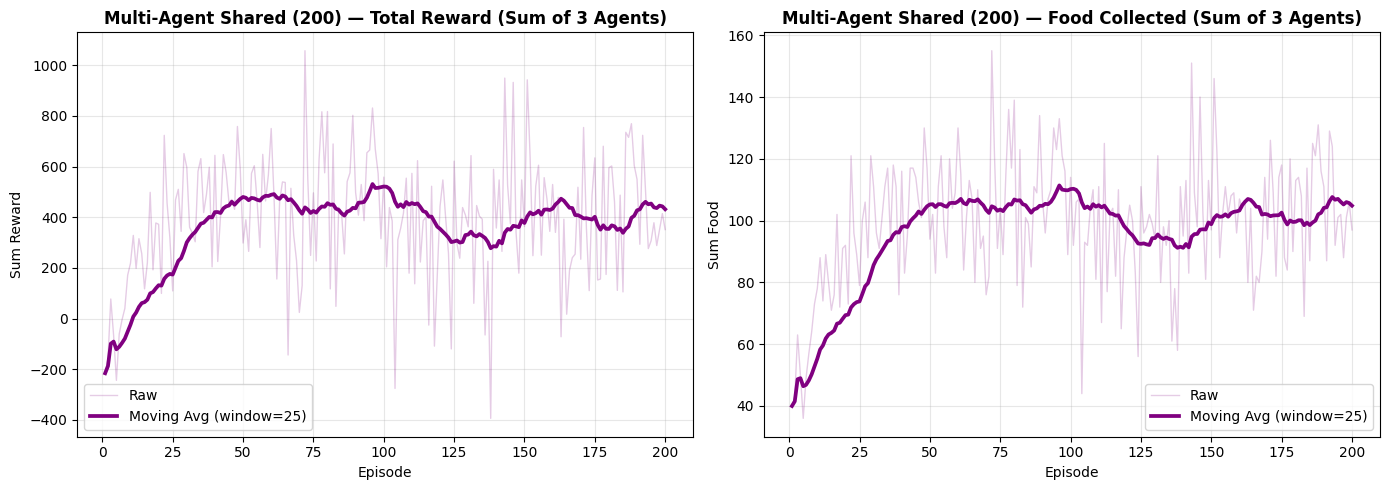

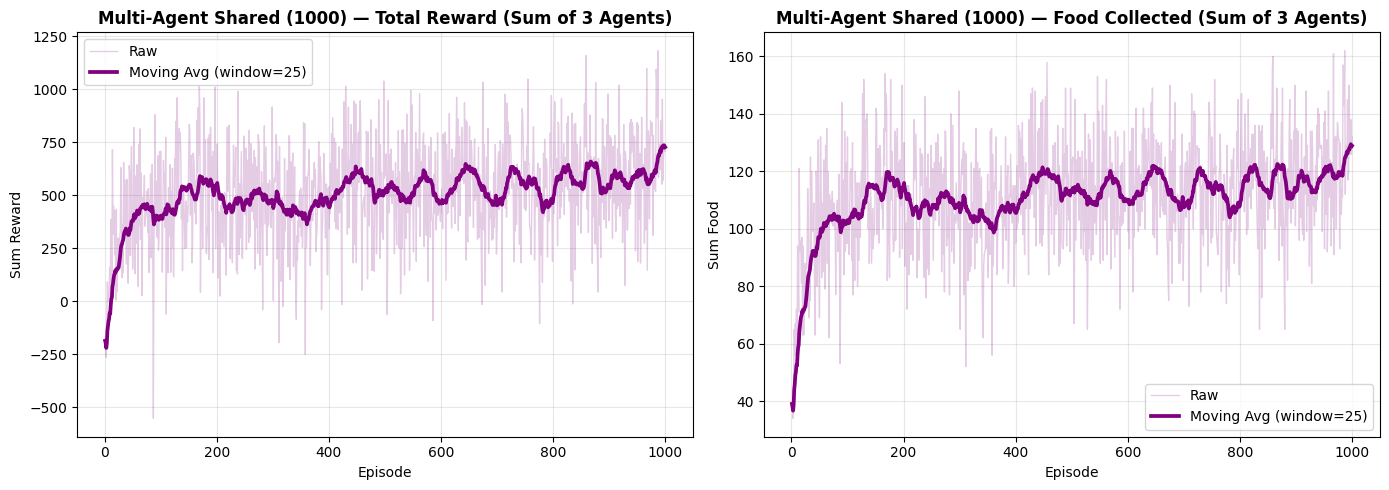

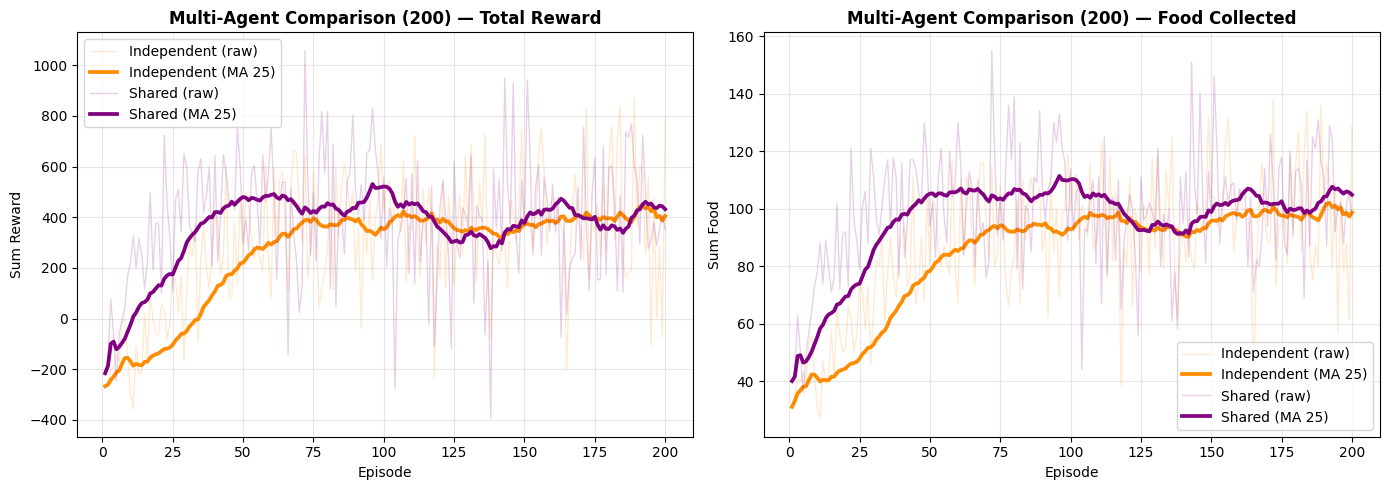

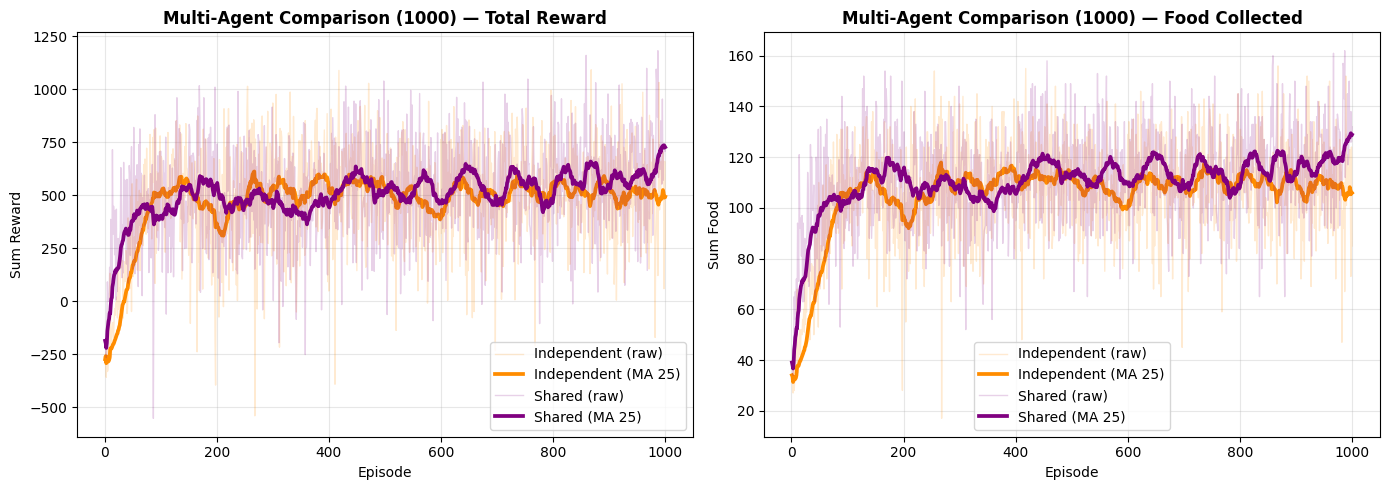

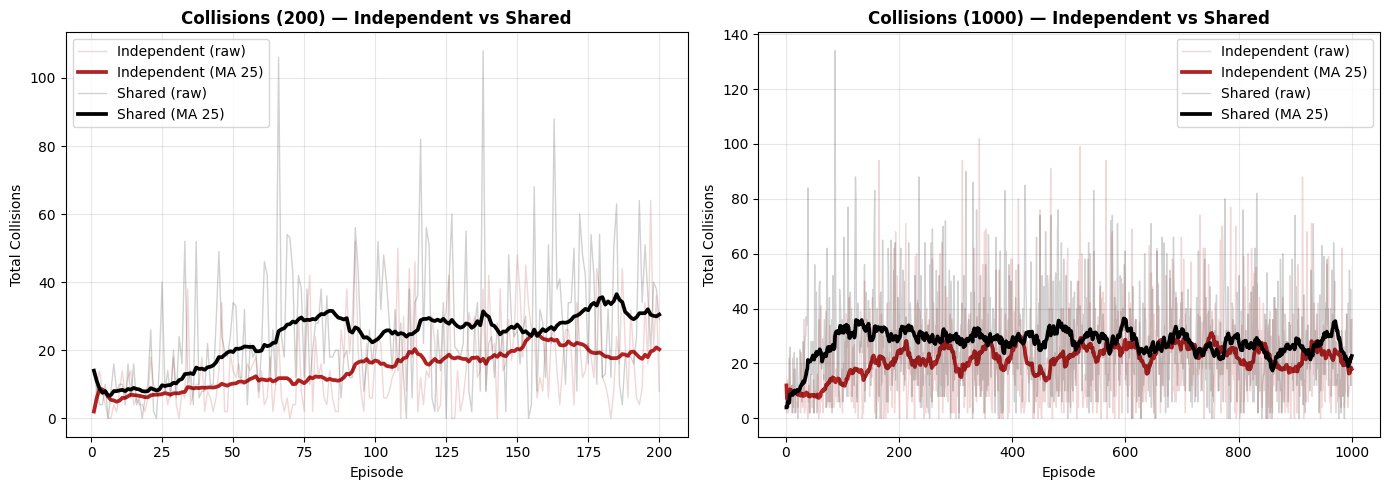

In [12]:
# =========================================================
# SIDE-BY-SIDE FIGURES (better for report)
# =========================================================

def plot_side_by_side_single(df, title_prefix, window=25,
                             color_reward="royalblue", color_food="seagreen"):
    """
    Makes 1 figure with 2 plots:
    (left) TotalReward vs Episode
    (right) FoodCollected vs Episode
    """
    x = df["Episode"].values

    y_r = df["TotalReward"].values
    y_r_ma = moving_average(y_r, window=window)

    y_f = df["FoodCollected"].values
    y_f_ma = moving_average(y_f, window=window)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Reward (left) ----
    axes[0].plot(x, y_r, color=color_reward, alpha=0.20, linewidth=1, label="Raw")
    axes[0].plot(x, y_r_ma, color=color_reward, linewidth=2.7, label=f"Moving Avg (window={window})")
    axes[0].set_title(f"{title_prefix} — Total Reward", fontweight="bold")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ---- Food (right) ----
    axes[1].plot(x, y_f, color=color_food, alpha=0.20, linewidth=1, label="Raw")
    axes[1].plot(x, y_f_ma, color=color_food, linewidth=2.7, label=f"Moving Avg (window={window})")
    axes[1].set_title(f"{title_prefix} — Food Collected", fontweight="bold")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Food Items")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_side_by_side_sum(curves_df, title_prefix, window=25,
                          color_reward="darkorange", color_food="darkorange"):
    """
    Makes 1 figure with 2 plots using SUM curves:
    (left) TotalReward_SumAgents
    (right) FoodCollected_SumAgents
    """
    x = curves_df["Episode"].values

    y_r = curves_df["TotalReward_SumAgents"].values
    y_r_ma = moving_average(y_r, window=window)

    y_f = curves_df["FoodCollected_SumAgents"].values
    y_f_ma = moving_average(y_f, window=window)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Reward sum (left) ----
    axes[0].plot(x, y_r, color=color_reward, alpha=0.20, linewidth=1, label="Raw")
    axes[0].plot(x, y_r_ma, color=color_reward, linewidth=2.7, label=f"Moving Avg (window={window})")
    axes[0].set_title(f"{title_prefix} — Total Reward (Sum of 3 Agents)", fontweight="bold")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Sum Reward")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ---- Food sum (right) ----
    axes[1].plot(x, y_f, color=color_food, alpha=0.20, linewidth=1, label="Raw")
    axes[1].plot(x, y_f_ma, color=color_food, linewidth=2.7, label=f"Moving Avg (window={window})")
    axes[1].set_title(f"{title_prefix} — Food Collected (Sum of 3 Agents)", fontweight="bold")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Sum Food")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_side_by_side_compare(ind_df, sh_df, title_prefix, window=25,
                              color_ind="darkorange", color_sh="purple"):
    """
    Makes 1 figure with 2 plots comparing Independent vs Shared:
    (left) TotalReward_SumAgents
    (right) FoodCollected_SumAgents
    """
    x = ind_df["Episode"].values

    yi_r = ind_df["TotalReward_SumAgents"].values
    ys_r = sh_df["TotalReward_SumAgents"].values
    yi_r_ma = moving_average(yi_r, window=window)
    ys_r_ma = moving_average(ys_r, window=window)

    yi_f = ind_df["FoodCollected_SumAgents"].values
    ys_f = sh_df["FoodCollected_SumAgents"].values
    yi_f_ma = moving_average(yi_f, window=window)
    ys_f_ma = moving_average(ys_f, window=window)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Reward compare (left) ----
    axes[0].plot(x, yi_r, color=color_ind, alpha=0.18, linewidth=1, label="Independent (raw)")
    axes[0].plot(x, yi_r_ma, color=color_ind, linewidth=2.7, label=f"Independent (MA {window})")
    axes[0].plot(x, ys_r, color=color_sh, alpha=0.18, linewidth=1, label="Shared (raw)")
    axes[0].plot(x, ys_r_ma, color=color_sh, linewidth=2.7, label=f"Shared (MA {window})")
    axes[0].set_title(f"{title_prefix} — Total Reward", fontweight="bold")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Sum Reward")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ---- Food compare (right) ----
    axes[1].plot(x, yi_f, color=color_ind, alpha=0.18, linewidth=1, label="Independent (raw)")
    axes[1].plot(x, yi_f_ma, color=color_ind, linewidth=2.7, label=f"Independent (MA {window})")
    axes[1].plot(x, ys_f, color=color_sh, alpha=0.18, linewidth=1, label="Shared (raw)")
    axes[1].plot(x, ys_f_ma, color=color_sh, linewidth=2.7, label=f"Shared (MA {window})")
    axes[1].set_title(f"{title_prefix} — Food Collected", fontweight="bold")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Sum Food")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_collisions_200_vs_1000(mi_200, ms_200, mi_1000, ms_1000, window=25,
                                color_ind="firebrick", color_sh="black"):
    """
    One figure:
    (left) collisions 200 Independent vs Shared
    (right) collisions 1000 Independent vs Shared
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- 200 collisions (left) ----
    x200 = mi_200["Episode"].values
    i200 = mi_200["TotalCollisions_SumAgents"].values
    s200 = ms_200["TotalCollisions_SumAgents"].values
    i200_ma = moving_average(i200, window=window)
    s200_ma = moving_average(s200, window=window)

    axes[0].plot(x200, i200, color=color_ind, alpha=0.18, linewidth=1, label="Independent (raw)")
    axes[0].plot(x200, i200_ma, color=color_ind, linewidth=2.7, label=f"Independent (MA {window})")
    axes[0].plot(x200, s200, color=color_sh, alpha=0.18, linewidth=1, label="Shared (raw)")
    axes[0].plot(x200, s200_ma, color=color_sh, linewidth=2.7, label=f"Shared (MA {window})")
    axes[0].set_title("Collisions (200) — Independent vs Shared", fontweight="bold")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Total Collisions")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # ---- 1000 collisions (right) ----
    x1000 = mi_1000["Episode"].values
    i1000 = mi_1000["TotalCollisions_SumAgents"].values
    s1000 = ms_1000["TotalCollisions_SumAgents"].values
    i1000_ma = moving_average(i1000, window=window)
    s1000_ma = moving_average(s1000, window=window)

    axes[1].plot(x1000, i1000, color=color_ind, alpha=0.18, linewidth=1, label="Independent (raw)")
    axes[1].plot(x1000, i1000_ma, color=color_ind, linewidth=2.7, label=f"Independent (MA {window})")
    axes[1].plot(x1000, s1000, color=color_sh, alpha=0.18, linewidth=1, label="Shared (raw)")
    axes[1].plot(x1000, s1000_ma, color=color_sh, linewidth=2.7, label=f"Shared (MA {window})")
    axes[1].set_title("Collisions (1000) — Independent vs Shared", fontweight="bold")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Total Collisions")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# =========================================================
# CALLS
# =========================================================

# Single-agent: reward + food side-by-side
plot_side_by_side_single(single_200,  "Single Agent (200)",  window=25)
plot_side_by_side_single(single_1000, "Single Agent (1000)", window=25)

# Multi-agent: independent reward + food side-by-side
plot_side_by_side_sum(mi_200_curves,  "Multi-Agent Independent (200)",  window=25, color_reward="darkorange", color_food="darkorange")
plot_side_by_side_sum(mi_1000_curves, "Multi-Agent Independent (1000)", window=25, color_reward="darkorange", color_food="darkorange")

# Multi-agent: shared reward + food side-by-side
plot_side_by_side_sum(ms_200_curves,  "Multi-Agent Shared (200)",  window=25, color_reward="purple", color_food="purple")
plot_side_by_side_sum(ms_1000_curves, "Multi-Agent Shared (1000)", window=25, color_reward="purple", color_food="purple")

# Independent vs Shared: reward + food side-by-side
plot_side_by_side_compare(mi_200_curves,  ms_200_curves,  "Multi-Agent Comparison (200)",  window=25)
plot_side_by_side_compare(mi_1000_curves, ms_1000_curves, "Multi-Agent Comparison (1000)", window=25)

# Collisions: 200 vs 1000 side-by-side (Independent vs Shared inside each)
plot_collisions_200_vs_1000(mi_200_curves, ms_200_curves, mi_1000_curves, ms_1000_curves, window=25)

## Results and Discussion

### Single Agent
- **Total reward trend:** (increasing / stable / fluctuating)  
- **Food collected trend:** (increasing / stable / fluctuating)  
Interpretation:
- If reward and food both increase over time, the agent is learning a better foraging policy.

### Multi-Agent: Independent vs Shared
Based on the plots:
- **Which learns faster?** (Independent or Shared)
- **Which achieves higher total reward?**
- **Which collects more food?**

### Cooperation vs Competition
Indicators:
- Higher **collision counts** suggest stronger competition/interference.
- If collisions decrease and food collection increases, agents may be implicitly “spreading out”.

Observation summary:
- Independent setup: (more collisions / less collisions / more variance)
- Shared setup: (faster learning / smoother curves / higher performance)
